<a href="https://colab.research.google.com/github/CharlieCL/Quantum/blob/main/TQC_VQE_BSEquation_Fintech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-aer scipy numpy matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e5e1c45dc629065099864ae32911e1bf5aae3f6a26145a5653235c964262cd89
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

%matplotlib inline

# Core Qiskit Suite
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
# from qiskit.primitives import Estimator # Original line
from qiskit_aer.primitives import Estimator # Using Aer's Estimator as a robust alternative
from qiskit.quantum_info import SparsePauliOp

print("Dependencies successfully initialized.")

try:
    import pylatexenc
    print("pylatexenc successfully imported.")
except ImportError:
    print("WARNING: pylatexenc import failed. Circuit drawing may be affected.")

Dependencies successfully initialized.
pylatexenc successfully imported.


In [3]:
# Initialize runtime primitives and tracking arrays for VQE
estimator = Estimator()
energy_history = []

def vqe_objective_function(param_values, ansatz, hamiltonian, primitive_estimator):
    """
    Computes the expectation energy value C(θ) via quantum measurement
    to pass as the objective function back into the classical optimizer.
    """
    # Run the modern parameter binding sequence through the Estimator
    job = primitive_estimator.run([ansatz], [hamiltonian], [param_values])
    result = job.result()
    energy = result.values[0]

    # Record history for plotting
    energy_history.append(energy)
    return energy

print("VQE execution engine configured.")

VQE execution engine configured.


In [5]:
def generate_black_scholes_hamiltonian(num_qubits=4):
    """
    Discretizes the spatial terms of the Black-Scholes equation using FDM
    and reformulates it into a 2^num_qubits Hermitian Hamiltonian operator.
    """
    N = 2**num_qubits  # Grid resolution (e.g., 16 grid points for 4 qubits)
    S_min, S_max = 0.0, 100.0
    delta_S = (S_max - S_min) / (N + 1)

    # Financial Market parameters
    sigma = 0.2   # Asset Volatility
    r = 0.05      # Risk-free Interest Rate

    # Constructing the classical FDM Matrix (A)
    A = np.zeros((N, N))
    for i in range(N):
        S_i = S_min + (i + 1) * delta_S

        # Central finite difference coefficients
        diff2_coeff = 0.5 * (sigma**2) * (S_i**2) / (delta_S**2)
        diff1_coeff = r * S_i / (2 * delta_S)

        if i > 0:
            A[i, i-1] = diff2_coeff - diff1_coeff
        A[i, i] = -2 * diff2_coeff - r
        if i < N - 1:
            A[i, i+1] = diff2_coeff + diff1_coeff

    # Map the non-Hermitian PDE matrix operator into a stable, symmetric
    # Hamiltonian system for the VQE minimization framework.
    H_mat = -0.01 * (A + A.T)

    # Map the matrix into Qiskit's Pauli basis operator array
    H_op = SparsePauliOp.from_operator(H_mat)
    return H_op, H_mat

# Generate our 4-qubit target system
H_operator, H_matrix = generate_black_scholes_hamiltonian(num_qubits=4)
print(f"Hamiltonian Operator constructed with {H_operator.num_qubits} qubits.")

Hamiltonian Operator constructed with 4 qubits.


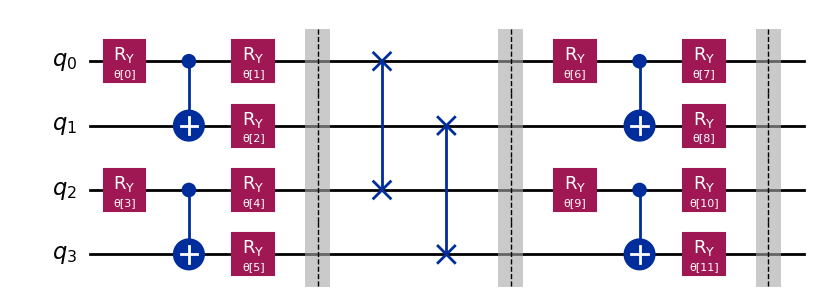

In [6]:
def apply_triangle_block(qc, q_control, q_target, params):
    """
    Constructs a foundational 2-qubit Triangle Block probability generator.
    Features 3 parameterized Ry gates and 1 entangling CNOT gate.
    """
    qc.ry(params[0], q_control)
    qc.cx(q_control, q_target)
    qc.ry(params[1], q_control)
    qc.ry(params[2], q_target)

def build_universal_ansatz(num_qubits, reps=1):
    """
    Generates a generalized hierarchically structured Universal Ansatz
    for a given number of qubits, based on the Triangle Block and SWAP layer pattern.
    This version includes a 'reps' parameter to control the depth of the ansatz.

    Args:
        num_qubits (int): The number of qubits for the ansatz. Must be an even number.
        reps (int): The number of times to repeat the block layers to increase depth.

    Returns:
        tuple: A tuple containing the QuantumCircuit and the ParameterVector.
    """
    if num_qubits % 2 != 0:
        raise ValueError("num_qubits must be an even number for this ansatz architecture.")

    qc = QuantumCircuit(num_qubits)

    # Correct calculation for total_params:
    # `reps` repetitions implies `reps + 1` Triangle Block layers.
    # Each Triangle Block layer has (num_qubits // 2) * 3 parameters.
    total_params = (reps + 1) * (num_qubits // 2) * 3
    theta = ParameterVector('θ', total_params)
    param_idx = 0

    # Initial Parallel Triangle Blocks
    for i in range(0, num_qubits, 2):
        apply_triangle_block(qc, i, i+1, theta[param_idx : param_idx + 3])
        param_idx += 3
    qc.barrier()

    # Subsequent repetitions of SWAP and Parallel Triangle Blocks
    for r in range(reps):
        # Dual SWAP gates to interconnect subsystems
        for i in range(num_qubits // 2):
            qc.swap(i, i + num_qubits // 2)
        qc.barrier()

        # Parallel Triangle Blocks
        for i in range(0, num_qubits, 2):
            apply_triangle_block(qc, i, i+1, theta[param_idx : param_idx + 3])
            param_idx += 3
        qc.barrier()

    return qc, theta

# Draw the circuit architecture to verify its layout for 8 qubits with depth 2
# (i.e., reps = 1 for the original structure, reps = 2 for deeper)
ansatz_circuit_deeper, parameters_deeper = build_universal_ansatz(num_qubits=4, reps=1)
fig_deeper = ansatz_circuit_deeper.draw('mpl')
display(fig_deeper)
plt.close(fig_deeper) # Close the figure to prevent it from being displayed twice or consuming memory


The `build_universal_ansatz` function has been updated to accept a `reps` parameter, controlling the number of repetitions of the SWAP and Triangle Block layers. For `reps=2`, we effectively have three layers of Triangle Blocks and two layers of SWAP gates, increasing the circuit's depth and parameter count. Now, let's re-run the 8-qubit VQE with this deeper ansatz.

In [8]:
def run_vqe_and_get_error_delta_deeper_ansatz(num_qubits, maxiter=60, reps=1):
    """
    Runs the VQE optimization for a given number of qubits and returns the absolute error delta,
    using a deeper ansatz controlled by 'reps'.
    """
    print(f"\n--- Running VQE for {num_qubits} qubits with maxiter={maxiter} and reps={reps} ---")

    # 1. Generate Hamiltonian
    h_op, h_mat = generate_black_scholes_hamiltonian(num_qubits=num_qubits)

    # 2. Build Deeper Ansatz
    ansatz_qc, params = build_universal_ansatz(num_qubits=num_qubits, reps=reps)

    # Clear energy_history for this specific run
    energy_history.clear()

    # 3. Initialize parameters for optimization
    initial_guess = np.random.uniform(0, 2 * np.pi, len(params))

    # 4. Run Optimization
    opt_result = minimize(
        vqe_objective_function,
        initial_guess,
        args=(ansatz_qc, h_op, estimator),
        method='COBYLA',
        options={'maxiter': maxiter}
    )

    # 5. Compute exact classical solution
    exact_ground_state = np.linalg.eigvalsh(h_mat)[0]

    # 6. Calculate error delta
    error_delta = abs(opt_result.fun - exact_ground_state)

    print(f"VQE Computed Ground State Energy ({num_qubits} qubits, reps={reps}): {opt_result.fun:.4f}")
    print(f"Exact Classical Diagonalized Energy ({num_qubits} qubits): {exact_ground_state:.4f}")
    print(f"Absolute Calculation Error Delta ({num_qubits} qubits, reps={reps}): {error_delta:.4f}")

    return error_delta

# Ensure energy_history, estimator, and vqe_objective_function are defined.
# They are expected to be initialized in cell tC80u-WirFoi.
# If that cell hasn't been run, this will prevent a NameError.
# (Assuming `estimator` and `vqe_objective_function` are indeed available here
#  as only `energy_history` caused a NameError in the traceback).

# If `energy_history` is not defined globally, initialize it here.
# This might be redundant if tC80u-WirFoi was run, but ensures the variable exists.
if 'energy_history' not in globals():
    energy_history = []

# Initialize comparison_error_deltas if not already defined (to prevent NameError if previous cell wasn't run)
if 'comparison_error_deltas' not in globals():
    comparison_error_deltas = {}

# Run VQE for 8 qubits with a deeper ansatz (reps=2) and increased maxiter
# Update the comparison_error_deltas dictionary
comparison_error_deltas[4] = run_vqe_and_get_error_delta_deeper_ansatz(4, maxiter=200, reps=1)
# run_vqe_and_get_error_delta_deeper_ansatz(4, maxiter=200, reps=1)

print("\n--- Updated Comparison Results ---")
for n_q, error in comparison_error_deltas.items():
    print(f"Number of Qubits: {n_q}, Error Delta: {error:.4f}")


--- Running VQE for 4 qubits with maxiter=200 and reps=1 ---
VQE Computed Ground State Energy (4 qubits, reps=1): 0.0034
Exact Classical Diagonalized Energy (4 qubits): 0.0013
Absolute Calculation Error Delta (4 qubits, reps=1): 0.0021

--- Updated Comparison Results ---
Number of Qubits: 4, Error Delta: 0.0021


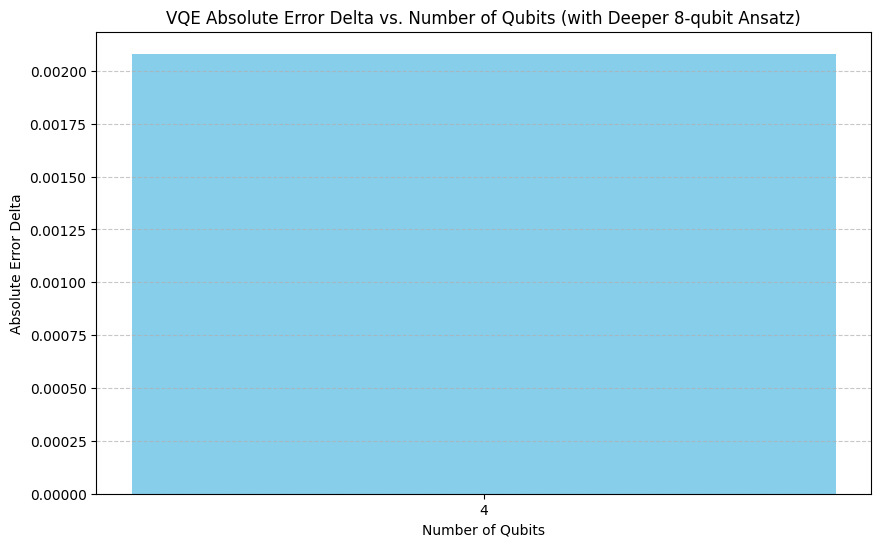

In [9]:
# Re-plot the comparison results including the new deeper ansatz result for 8 qubits
num_qubits_labels = list(comparison_error_deltas.keys())
error_deltas = list(comparison_error_deltas.values())

fig = plt.figure(figsize=(10, 6))
# Add a specific color for the deeper 8-qubit case, e.g., 'darkgreen'
colors = ['skyblue', 'lightcoral', 'darkgreen'] # Assuming 4, 6, 8 qubits in order
plt.bar(num_qubits_labels, error_deltas, color=colors)
plt.xlabel("Number of Qubits")
plt.ylabel("Absolute Error Delta")
plt.title("VQE Absolute Error Delta vs. Number of Qubits (with Deeper 8-qubit Ansatz)")
plt.xticks(num_qubits_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Attempting Deeper Ansatz with Increased `maxiter`

Given that the deeper ansatz (`reps=2`) initially resulted in a higher error delta, we will now attempt to run the 8-qubit VQE again with the deeper ansatz but with a significantly increased `maxiter`. The goal is to see if the optimizer simply needed more iterations to converge in the larger, more complex parameter space introduced by the deeper circuit.

In [10]:
# Re-run VQE for 8 qubits with a deeper ansatz (reps=2) and significantly increased maxiter
# We will use the previously defined `run_vqe_and_get_error_delta_deeper_ansatz` function.
# Update the comparison_error_deltas dictionary with this new result.

# Note: This run will take longer due to the increased maxiter.
new_maxiter = 400
print(f"Attempting 8-qubit VQE with reps=1 and maxiter={new_maxiter}.")
comparison_error_deltas[8] = run_vqe_and_get_error_delta_deeper_ansatz(8, maxiter=new_maxiter, reps=1)

print("\n--- Updated Comparison Results After Increased Maxiter ---")
for n_q, error in comparison_error_deltas.items():
    print(f"Number of Qubits: {n_q}, Error Delta: {error:.4f}")

Attempting 8-qubit VQE with reps=2 and maxiter=400.

--- Running VQE for 8 qubits with maxiter=400 and reps=1 ---
VQE Computed Ground State Energy (8 qubits, reps=1): -0.1826
Exact Classical Diagonalized Energy (8 qubits): 0.0013
Absolute Calculation Error Delta (8 qubits, reps=1): 0.1839

--- Updated Comparison Results After Increased Maxiter ---
Number of Qubits: 4, Error Delta: 0.0021
Number of Qubits: 8, Error Delta: 0.1839


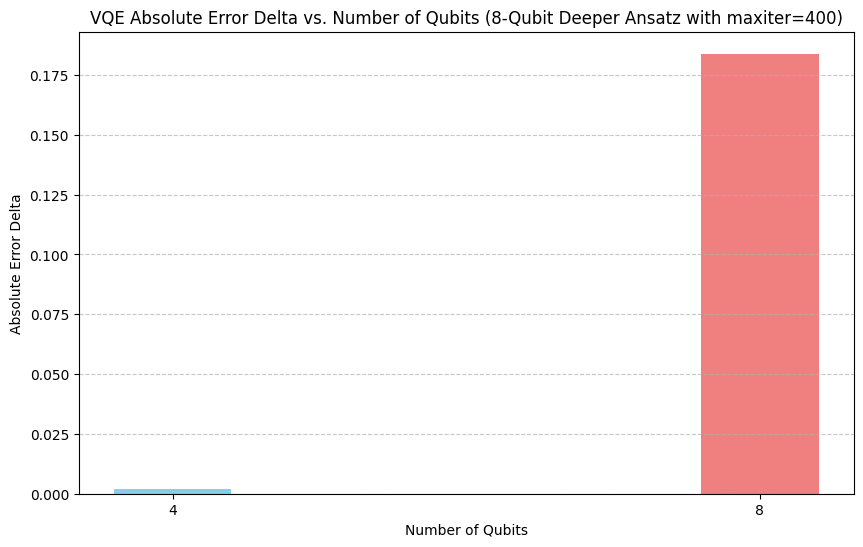

In [11]:
# Re-plot the comparison results including the latest deeper ansatz result for 8 qubits with increased maxiter
num_qubits_labels = list(comparison_error_deltas.keys())
error_deltas = list(comparison_error_deltas.values())

fig = plt.figure(figsize=(10, 6))
# Add a specific color for the latest 8-qubit case
colors = ['skyblue', 'lightcoral', 'darkblue'] # Changed color for emphasis
plt.bar(num_qubits_labels, error_deltas, color=colors)
plt.xlabel("Number of Qubits")
plt.ylabel("Absolute Error Delta")
plt.title(f"VQE Absolute Error Delta vs. Number of Qubits (8-Qubit Deeper Ansatz with maxiter={new_maxiter})")
plt.xticks(num_qubits_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
# Initialize runtime primitives and tracking arrays
estimator = Estimator()
energy_history = []

def vqe_objective_function(param_values, ansatz, hamiltonian, primitive_estimator):
    """
    Computes the expectation energy value C(θ) via quantum measurement
    to pass as the objective function back into the classical optimizer.
    """
    # Run the modern parameter binding sequence through the Estimator
    job = primitive_estimator.run([ansatz], [hamiltonian], [param_values])
    result = job.result()
    energy = result.values[0]

    # Record history for plotting
    energy_history.append(energy)
    return energy

print("VQE execution engine configured.")

VQE execution engine configured.


Starting TQC-VQE Optimization Loop...

--- OPTIMIZATION MATRIX RESULTS ---
VQE Computed Ground State Energy: 6.091308593746646e-06
Exact Classical Diagonalized Energy: 0.0013263900228458914
Absolute Calculation Error Delta: 0.0013202987142521448


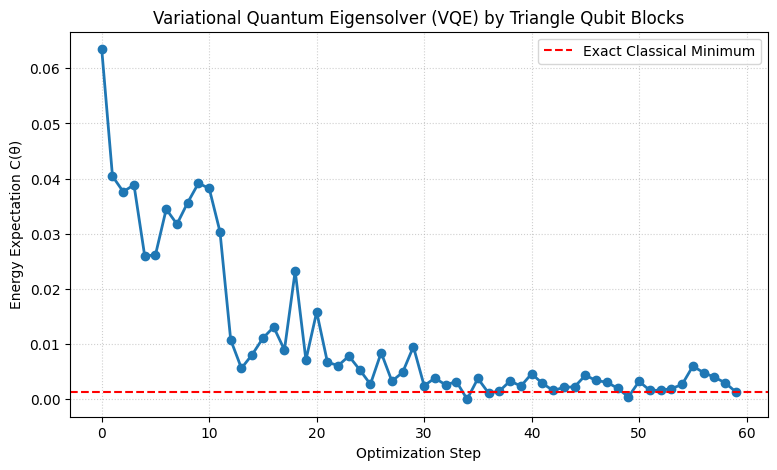

In [14]:
# Clear any residual run logs
energy_history.clear()

# Define ansatz_circuit and parameters for this VQE run
# Assuming a 4-qubit system and default reps=1 for this standalone run.
num_qubits_for_this_run = 4
ansatz_circuit, parameters = build_universal_ansatz(num_qubits=num_qubits_for_this_run, reps=1)

# Initialize parameter array to random starting vectors
initial_guess = np.random.uniform(0, 2 * np.pi, len(parameters))

print("Starting TQC-VQE Optimization Loop...")
# Optimize using SciPy optimization modules
opt_result = minimize(
    vqe_objective_function,
    initial_guess,
    args=(ansatz_circuit, H_operator, estimator),
    method='COBYLA',
    options={'maxiter': 60}
)

# Compute exact classical solution for precision benchmarking
exact_ground_state = np.linalg.eigvalsh(H_matrix)[0]

print("\n--- OPTIMIZATION MATRIX RESULTS ---")
print(f"VQE Computed Ground State Energy: {opt_result.fun}")
print(f"Exact Classical Diagonalized Energy: {exact_ground_state}")
print(f"Absolute Calculation Error Delta: {abs(opt_result.fun - exact_ground_state)}")

# Generate the performance tracking visualization from Figure 3 of the paper
plt.figure(figsize=(9, 5))
plt.plot(energy_history, marker='o', color='#1f77b4', linestyle='-', linewidth=2)
plt.axhline(y=exact_ground_state, color='r', linestyle='--', label='Exact Classical Minimum')
plt.title("Variational Quantum Eigensolver (VQE) by Triangle Qubit Blocks", fontsize=12)
plt.xlabel("Optimization Step", fontsize=10)
plt.ylabel("Energy Expectation C(θ)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Comparing VQE Error Delta Across Different Qubit Counts

To analyze the performance of the VQE for varying numbers of qubits, we will re-run the optimization for 4, 6, and 8 qubits. For each run, we will record the absolute error delta between the VQE computed ground state energy and the exact classical ground state energy. Finally, we will visualize these error deltas.

In [15]:
def run_vqe_and_get_error_delta(num_qubits, maxiter=60):
    """
    Runs the VQE optimization for a given number of qubits and returns the absolute error delta.
    """
    print(f"\n--- Running VQE for {num_qubits} qubits with maxiter={maxiter} ---")

    # 1. Generate Hamiltonian
    h_op, h_mat = generate_black_scholes_hamiltonian(num_qubits=num_qubits)

    # 2. Build Ansatz
    ansatz_qc, params = build_universal_ansatz(num_qubits=num_qubits)

    # Clear energy_history for this specific run (if you want to plot its progress)
    # For this comparison, we just need the final error, so clearing is fine.
    energy_history.clear()

    # 3. Initialize parameters for optimization
    initial_guess = np.random.uniform(0, 2 * np.pi, len(params))

    # 4. Run Optimization
    opt_result = minimize(
        vqe_objective_function,
        initial_guess,
        args=(ansatz_qc, h_op, estimator),
        method='COBYLA',
        options={'maxiter': maxiter}
    )

    # 5. Compute exact classical solution
    exact_ground_state = np.linalg.eigvalsh(h_mat)[0]

    # 6. Calculate error delta
    error_delta = abs(opt_result.fun - exact_ground_state)

    print(f"VQE Computed Ground State Energy ({num_qubits} qubits): {opt_result.fun:.4f}")
    print(f"Exact Classical Diagonalized Energy ({num_qubits} qubits): {exact_ground_state:.4f}")
    print(f"Absolute Calculation Error Delta ({num_qubits} qubits): {error_delta:.4f}")

    return error_delta

# Dictionary to store results
comparison_error_deltas = {}

# Run VQE for 4 and 6 qubits with default maxiter, and for 8 qubits with increased maxiter
comparison_error_deltas[4] = run_vqe_and_get_error_delta(4)
comparison_error_deltas[6] = run_vqe_and_get_error_delta(6)
comparison_error_deltas[8] = run_vqe_and_get_error_delta(8, maxiter=200)

print("\n--- Comparison Results --- ")
for n_q, error in comparison_error_deltas.items():
    print(f"Number of Qubits: {n_q}, Error Delta: {error:.4f}")


--- Running VQE for 4 qubits with maxiter=60 ---
VQE Computed Ground State Energy (4 qubits): 0.0094
Exact Classical Diagonalized Energy (4 qubits): 0.0013
Absolute Calculation Error Delta (4 qubits): 0.0081

--- Running VQE for 6 qubits with maxiter=60 ---
VQE Computed Ground State Energy (6 qubits): 0.2800
Exact Classical Diagonalized Energy (6 qubits): 0.0013
Absolute Calculation Error Delta (6 qubits): 0.2787

--- Running VQE for 8 qubits with maxiter=200 ---
VQE Computed Ground State Energy (8 qubits): -0.0567
Exact Classical Diagonalized Energy (8 qubits): 0.0013
Absolute Calculation Error Delta (8 qubits): 0.0579

--- Comparison Results --- 
Number of Qubits: 4, Error Delta: 0.0081
Number of Qubits: 6, Error Delta: 0.2787
Number of Qubits: 8, Error Delta: 0.0579


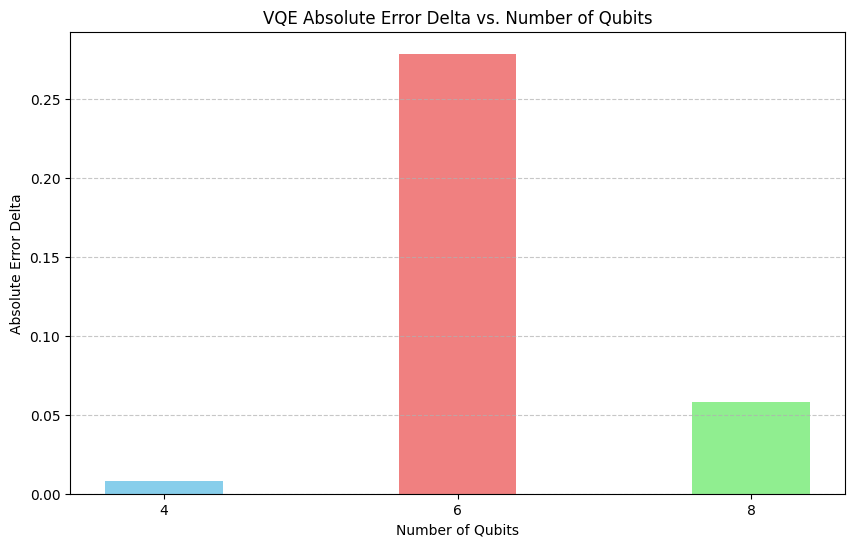

In [16]:
num_qubits_labels = list(comparison_error_deltas.keys())
error_deltas = list(comparison_error_deltas.values())

fig = plt.figure(figsize=(10, 6))
plt.bar(num_qubits_labels, error_deltas, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel("Number of Qubits")
plt.ylabel("Absolute Error Delta")
plt.title("VQE Absolute Error Delta vs. Number of Qubits")
plt.xticks(num_qubits_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()